In [1]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor

In [9]:
x_grid = np.linspace(-10, 10, 100).reshape(-1, 1)

In [10]:
y_grid = x_grid ** 2

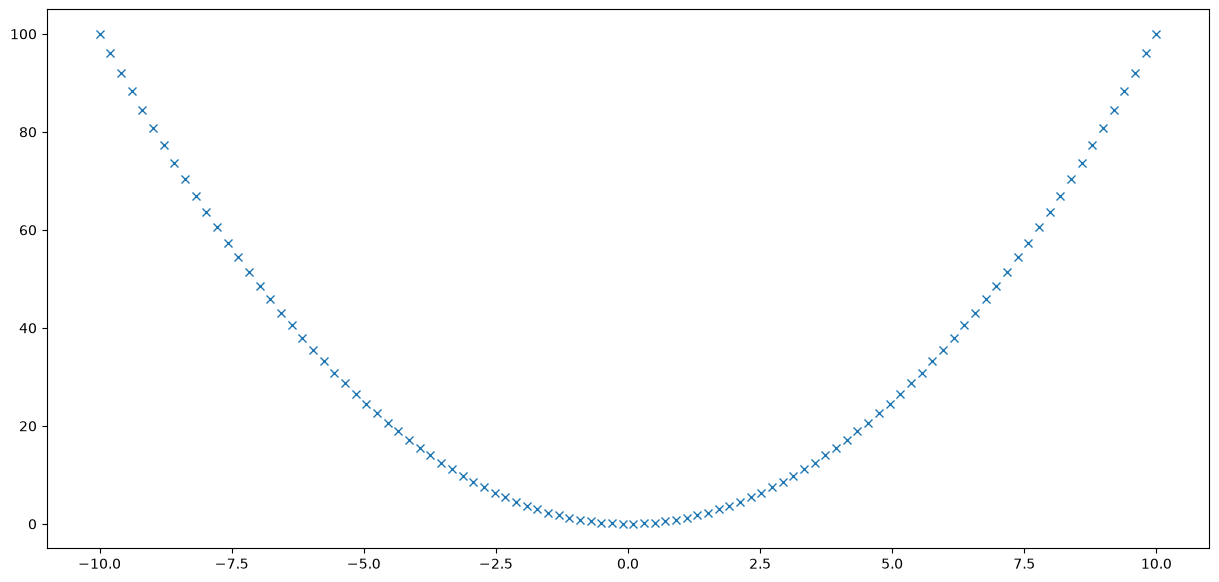

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (15, 7))
ax.plot(x_grid, y_grid, 'x', label = 'f(x)')


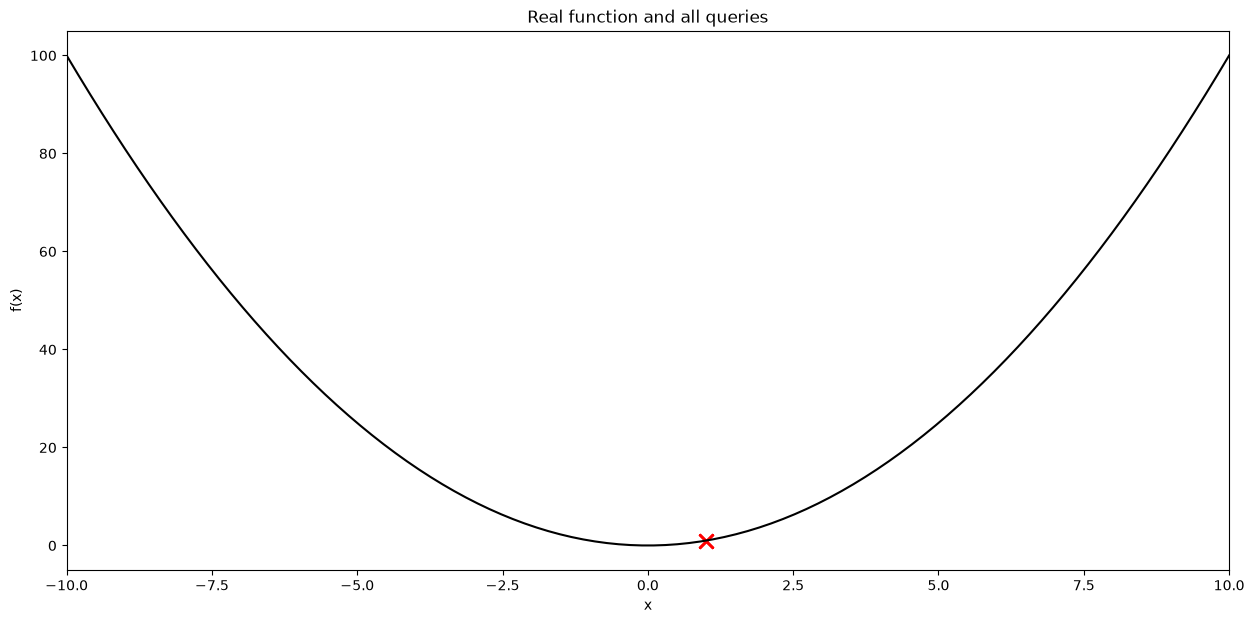

Maximum (by Grid-Search):
100.0
Best by Yourself:
1


In [15]:
from IPython.core.display_functions import clear_output

#Draw random function parameters
modes = np.random.randint(1, 5)
std = np.random.uniform(low = 0.005, high = 0.05, size = modes)
means = np.random.uniform(size = modes)
amps = np.random.uniform(size = modes) * (2 - 1) + 1

#Define function
def calc_function(x):
  return x**2

#Initialise query lists and maximum observations
X, Y = [], []
max_obs = 0

#Number of queries in the optimisation loop
num_queries = 10

for i in range(0, num_queries):
  #Clear the outputs to keep the interface clean
  clear_output(wait = True)
  #Initialise plots
  fig, ax = plt.subplots(figsize = (15, 7))
  #Set the x and y limits, labels and dynamic title
  ax.set_xlim(0, 1)
  ax.set_ylim(0, max(max_obs + 1, 3))
  ax.set_ylabel('f(x)')
  ax.set_xlabel('x')
  ax.set_title('So far you have selected ' + str(i) + ' queries, you have ' + str(10 - i) + ' left.' )
  #Plot queries and show the plot
  ax.scatter(X, Y, c = 'r', marker='x', s = 100)
  plt.show()
  #Initialise x
  x = -1
  #Select a display format for X and Y
  X_format =  ['%.2f' % query for query in X] #Two sig figs
  Y_format = ['%.4f' % obs for obs in Y] #Four sig figs

  while not (0 <= x <= 1): #Condition to ensure a number between zero and one is chosen
    data = [(query, obs) for query, obs in zip(X_format, Y_format)]
    print('Data so far (sorted by descending observations): ')
    print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start = 1))) #Display data
    x = 1
  #Append data, calculate function and sort lists according to observation values
  X.append(x)
  y = calc_function(x)
  Y.append(y)
  X = [x for _, x in sorted(zip(Y, X), reverse = True)]
  Y.sort(reverse = True)
  max_obs = max(max_obs, y)

clear_output()

#Calculate function in the grid [0, 0.01, 0.02, ..., 0.98, 0.99, 1]
x_grid = np.linspace(-10, 10, 100)
y_real = []
best_obs_grid = 0
for x in x_grid:
  y = calc_function(x)
  y_real.append(y)
  best_obs_grid = max(best_obs_grid, y) #Keep track of the best observation


#Final plot and display
fig, ax = plt.subplots(figsize = (15, 7))
ax.plot(x_grid, y_real, 'k', label = 'f(x)')
ax.scatter(X, Y, c = 'r', marker = 'x', label = 'Queries', s = 100)
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
ax.set_xlim(-10, 10)
ax.set_title('Real function and all queries')
plt.show()
print('Maximum (by Grid-Search):')
print(best_obs_grid)
print('Best by Yourself:')
print(max_obs)

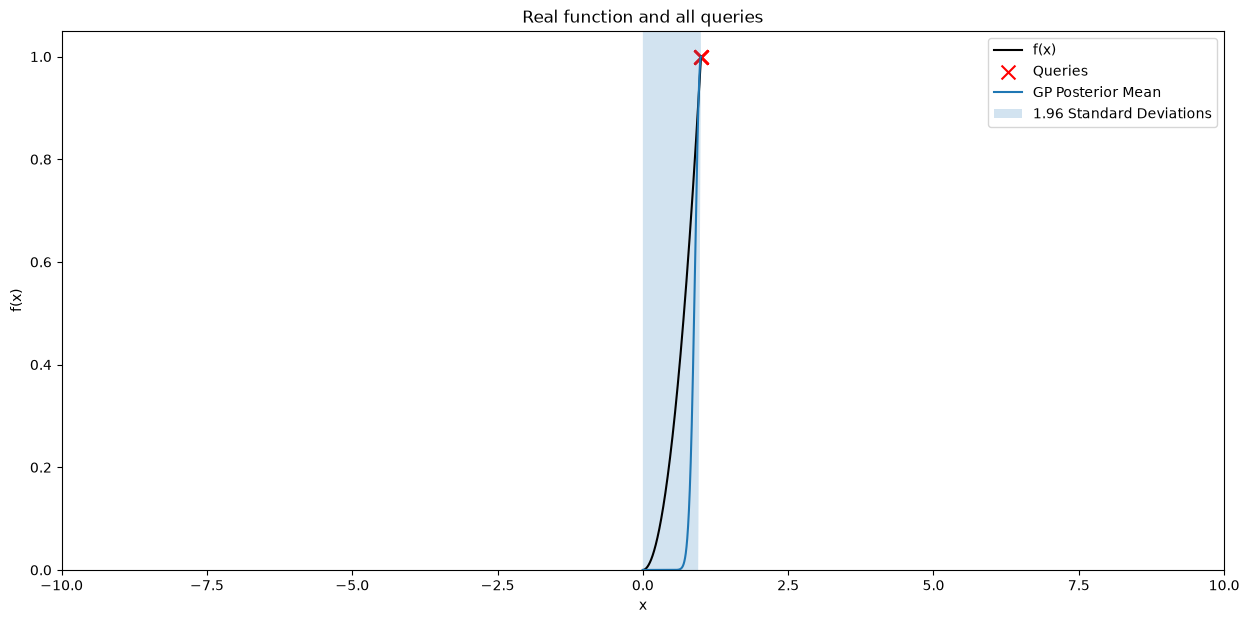

Maximum (by Grid-Search):
1.0
Best by Yourself:
1.0000000003374279


In [17]:
from sklearn.gaussian_process.kernels import RBF

#Parameters of the problem. Feel free to change them and play around with
real_noise_std = 1e-10 #Real noise needs to be positive for code to work, instead of zero set 1e-10
noise_assumption = 1e-10 #Noise assumption, a hyperparameter

rbf_lengthscale = 0.1 #Length scale parameter

#Draw random function parameters
modes = np.random.randint(1, 5)
std = np.random.uniform(low = 0.005, high = 0.05, size = modes)
means = np.random.uniform(size = modes)
amps = np.random.uniform(size = modes) * (2 - 1) + 1

#Define the kernel of the GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)
#Standard deviation for plot
beta = 1.96

#Define function

#Initialise query lists and maximum observations
X, Y = [], []
max_obs = 0
#Initialise grid for plots
x_grid = np.linspace(-10, 10, 10).reshape(-1, 1)

#Number of queries in the optimisation loop
num_queries = 10

for i in range(0, num_queries):
  #Clear the outputs to keep the interface clean
  clear_output(wait = True)
  model = GaussianProcessRegressor(kernel = kernel)
  #Fit the model
  if i != 0:
    model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))
  #Calculate mean and standard deviation and make them one-dimensional for plotting
  post_mean, post_std = model.predict(x_grid, return_std=True)
  post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

  #Initialise plots
  fig, ax = plt.subplots(figsize = (15, 7))
  #Set the x and y limits, labels and dynamic title
  ax.set_xlim(0, 1)
  ax.set_ylim(0, max(max_obs + 1, 3))
  ax.set_ylabel('f(x)')
  ax.set_xlabel('x')
  ax.set_title('So far you have selected ' + str(i) + ' queries, you have ' + str(10 - i) + ' left.' )
  #Plot queries
  ax.scatter(X, Y, c = 'r', marker='x', s = 100)
  #Plot mean and standard deviations
  ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
  ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
  ax.legend()
  plt.show()
  #Initialise x
  x = -1
  #Select a display format for X and Y
  X_format =  ['%.2f' % query for query in X] #Two sig figs
  Y_format = ['%.4f' % obs for obs in Y] #Four sig figs

  while not (0 <= x <= 1): #Condition to ensure a number between zero and one is chosen
    data = [(query, obs) for query, obs in zip(X_format, Y_format)]
    print('Data so far (sorted by descending observations): ')
    print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start = 1))) #Display data
    x = 1
  #Append data, calculate function and sort lists according to observation values
  X.append(x)
  y = calc_function(x) + np.random.normal(scale = real_noise_std)
  Y.append(y)
  #Sort (X, Y) by descending Y: shows best values first,
  #But loses the original query order.
  X = [x for _, x in sorted(zip(Y, X), reverse = True)]
  Y.sort(reverse = True)
  max_obs = max(max_obs, y)

clear_output()

#Calculate function in the grid [0, 0.01, 0.02, ..., 0.98, 0.99, 1]
x_grid = np.linspace(0, 1, 1001)
y_real = []
best_obs_grid = 0
for x in x_grid:
  y = calc_function(x)
  y_real.append(y)
  best_obs_grid = max(best_obs_grid, y) #Keep track of the best observation


#Final GP posterior
model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))
post_mean, post_std = model.predict(x_grid.reshape(-1, 1), return_std=True)
post_mean, post_std = post_mean.squeeze(), post_std.squeeze()


#Final plot and display
fig, ax = plt.subplots(figsize = (15, 7))
#Plot GP posterior mean and ~95% confidence band (beta=1.96, not Upper Confidence Bound)
ax.plot(x_grid, y_real, 'k', label = 'f(x)')
ax.scatter(X, Y, c = 'r', marker = 'x', label = 'Queries', s = 100)
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
ax.set_xlim(-10, 10)
ax.set_ylim(bottom = 0)
ax.set_title('Real function and all queries')
ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
plt.show()
print('Maximum (by Grid-Search):')
print(best_obs_grid)
print('Best by Yourself:')
print(max_obs)

In [18]:
model.kernel

RBF(length_scale=0.1)

In [19]:
import numpy as np

# Kernel matrix
K = np.array([
    [1.000, 0.607, 0.135],
    [0.607, 1.000, 0.607],
    [0.135, 0.607, 1.000]
])

# Observed outputs
y = np.array([
    1,
    4,
    9
])

# Solve Kα = y
alpha = np.linalg.solve(K, y)

print(alpha)

[ 1.83637836 -3.84323616 11.08493327]


In [20]:
import numpy as np

K = np.array([
    [1.000, 0.607, 0.135],
    [0.607, 1.000, 0.607],
    [0.135, 0.607, 1.000]
])

y = np.array([
    1,
    4,
    9
])

K_inv = np.linalg.inv(K)

print("K^-1")
print(K_inv)

alpha = K_inv @ y

print("\nWeights (alpha)")
print(alpha)

K^-1
[[ 1.83399421 -1.52473487  0.67792485]
 [-1.52473487  2.85102813 -1.52473487]
 [ 0.67792485 -1.52473487  1.83399421]]

Weights (alpha)
[ 1.83637836 -3.84323616 11.08493327]
